*Computer Assignment: Sparse Signal Recovery with Various Sensing Matrices $A$*

# Part 1

Suppose that we have a signal $x$ of 256 samples ($N = 256$) where only 5 of these samples are nonzero ($S = 5$). The location and magnitude of these nonzero samples are unknown. Let’s investigate the problem of sampling this sparse signal using the various sampling methods.

In [1]:
# First import the necessaries libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import code from previous homework, using notebook import this time
from HW2 import (
    set_random_seed,
    generate_signal,
    plot_solution,
    plot_measurement_matrix,
    solve_l1_linear_programming,
    solve_matching_pursuit,
    solve_orthogonal_matching_pursuit,
    solve_subspace_pursuit,
    solve_cosamp,
    test_algorithm_on_signal
)

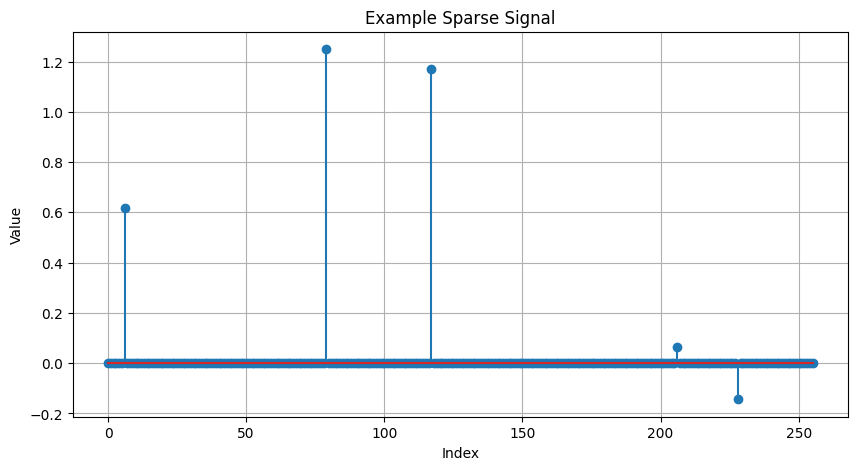

In [2]:
# Generate set of test signals
set_random_seed(42)

# The signal to recover
N = 256  # Signal dimension
S = 5   # Sparsity level
M_values = [i for i in range(10, 101, 10)]  # Number of measurements to test

x_list = [generate_signal(N, S) for _ in range(100)] # Generate 100 random signals

# Plot the first signal
plot_solution(x_list[0], title="Example Sparse Signal")

We need to test the performance of differnt kind of sensing matrices.

## Part a. Random sampling in the time domain

Suppose $I$ is the $N \times N$ identity matrix. Create the sensing matrix $A$ by keeping $M$ rows of $I$ at random locations (and deleting the remaining $N - M$ rows).

In [3]:
# We need a function to generate the measurement matrix and perform the recovery.
def generate_measurement_matrix_random_time(M, N):
    """
    Generate a random measurement matrix in the time domain.
    Each row is a random selection of the standard basis vectors.
    Parameters:
        M (int): Number of measurements (rows). Must be less than N.
        N (int): Signal dimension (columns).
    Returns:
        A (ndarray): Measurement matrix of shape (M, N).
    """
    if M >= N:
        raise ValueError("M must be less than N for a valid measurement matrix.")
    
    # Create an identity matrix of size N
    I = np.eye(N)
    
    # Randomly select M rows from the identity matrix
    selected_rows = np.random.choice(N, M, replace=False)
    
    # Construct the measurement matrix by selecting the corresponding rows
    A = I[selected_rows, :]
    
    return A

In [4]:
# Generate a lists of sensing matrices for different M
A_list_a = [generate_measurement_matrix_random_time(M, N) for M in M_values]

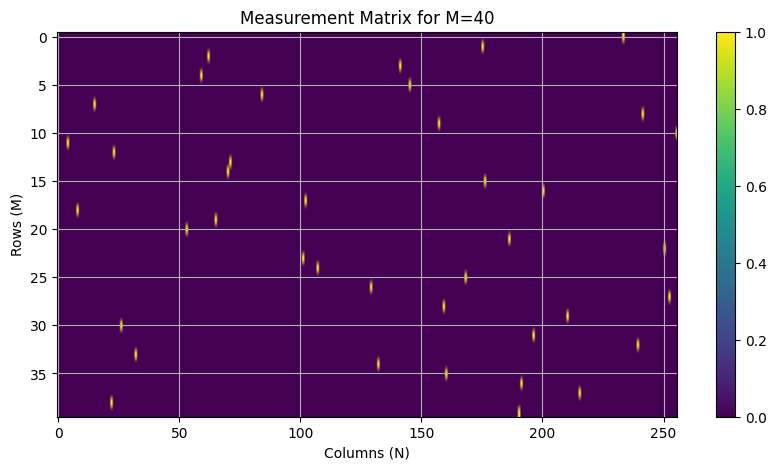

In [5]:
# Plot a matrix
plot_measurement_matrix(A_list_a[3], title=f"Measurement Matrix for M={M_values[3]}")

In [6]:
# Let's make a function to test the algorithms performance on a list of signals and measurement matrices.
algorithms = {
    "L1 Linear Programming": solve_l1_linear_programming,
    "Matching Pursuit": solve_matching_pursuit,
    "Orthogonal Matching Pursuit": solve_orthogonal_matching_pursuit,
    # "Subspace Pursuit": solve_subspace_pursuit,
    # "CoSaMP": solve_cosamp
} # Run only 3 algorithms to save time


def test_algorithms_on_signals(algorithms, A_list, x_list):
    results = {alg: {M: [] for M in M_values} for alg in algorithms.keys()}
    
    for A in (loop := tqdm(A_list)):
        M = A.shape[0]
        loop.set_description(f"Testing M={M}")
        for x in tqdm(x_list, leave=False):
            # print(f"Testing signal with {M} measurements")
            for alg_name, alg_func in algorithms.items():
                success = test_algorithm_on_signal(alg_func, A, x, S)
                results[alg_name][M].append(success)
    return results

# Make a function to plot the results
def plot_algorithm_performance(results):
    plt.figure(figsize=(12, 8))
    for alg_name, alg_results in results.items():
        M_values = sorted(alg_results.keys())
        success_rates = [np.mean(alg_results[M]) for M in M_values]
        plt.plot(M_values, success_rates, marker='o', label=alg_name)
    
    plt.title("Algorithm Performance vs Number of Measurements")
    plt.xlabel("Number of Measurements (M)")
    plt.ylabel("Recovery Success Rate")
    plt.ylim(0, 1.05)
    plt.xticks(M_values)
    plt.grid()
    plt.legend()
    plt.show()

Testing M=100: 100%|██████████| 10/10 [00:04<00:00,  2.14it/s]


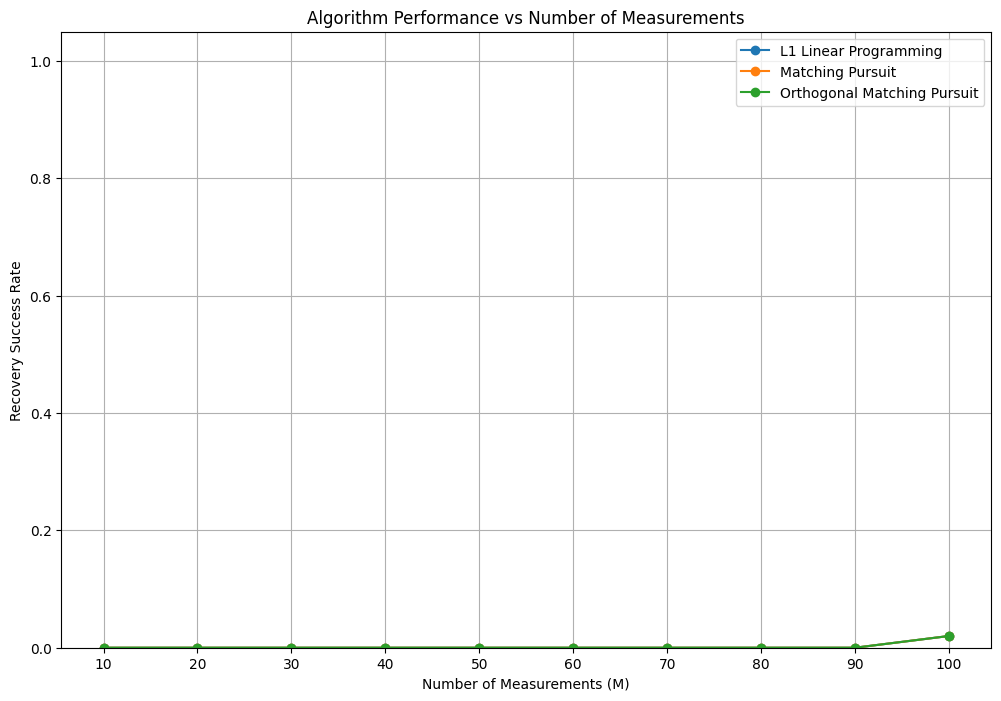

In [7]:
# Test the algorithms on the signals and plot the results
results_a = test_algorithms_on_signals(algorithms, A_list_a, x_list)
plot_algorithm_performance(results_a)

## Part b. Uniform subsampling in the time domain

The sensing matrix $A$ in this case is constructed by selecting $M$ rows of $I$ whose row indices are in the uniformly-spaced set $\{0, \lfloor N/M \rfloor, 2\lfloor N/M \rfloor, \dots, (M-1)\lfloor N/M \rfloor\}$.

In [8]:
# Function to generate uniform subsampling measurement matrix in time domain
def generate_measurement_matrix_uniform_time(M, N):
    """
    Generate a uniform subsampling measurement matrix in the time domain.
    Each row corresponds to a uniformly spaced sample of the signal.
    Parameters:
        M (int): Number of measurements (rows). Must be less than N.
        N (int): Signal dimension (columns).
    Returns:
        A (ndarray): Measurement matrix of shape (M, N).
    """
    if M >= N:
        raise ValueError("M must be less than N for a valid measurement matrix.")
    
    # Create an identity matrix of size N
    I = np.eye(N)
    
    # Uniformly select M rows from the identity matrix
    step = N // M
    selected_rows = np.arange(0, N, step)[:M]  # Ensure we only take M rows
    
    # Construct the measurement matrix by selecting the corresponding rows
    A = I[selected_rows, :]
    
    return A

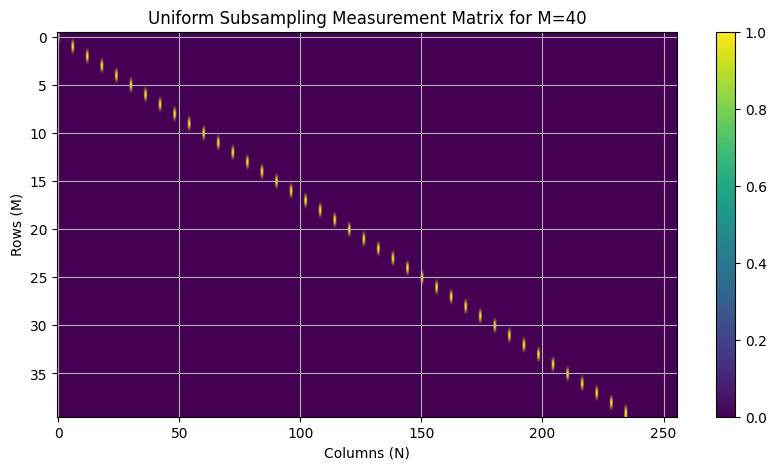

In [9]:
# Generate a lists of sensing matrices for different M
A_list_b = [generate_measurement_matrix_uniform_time(M, N) for M in M_values]

# Plot a matrix
plot_measurement_matrix(A_list_b[3], title=f"Uniform Subsampling Measurement Matrix for M={M_values[3]}")

Testing M=100: 100%|██████████| 10/10 [00:04<00:00,  2.07it/s]


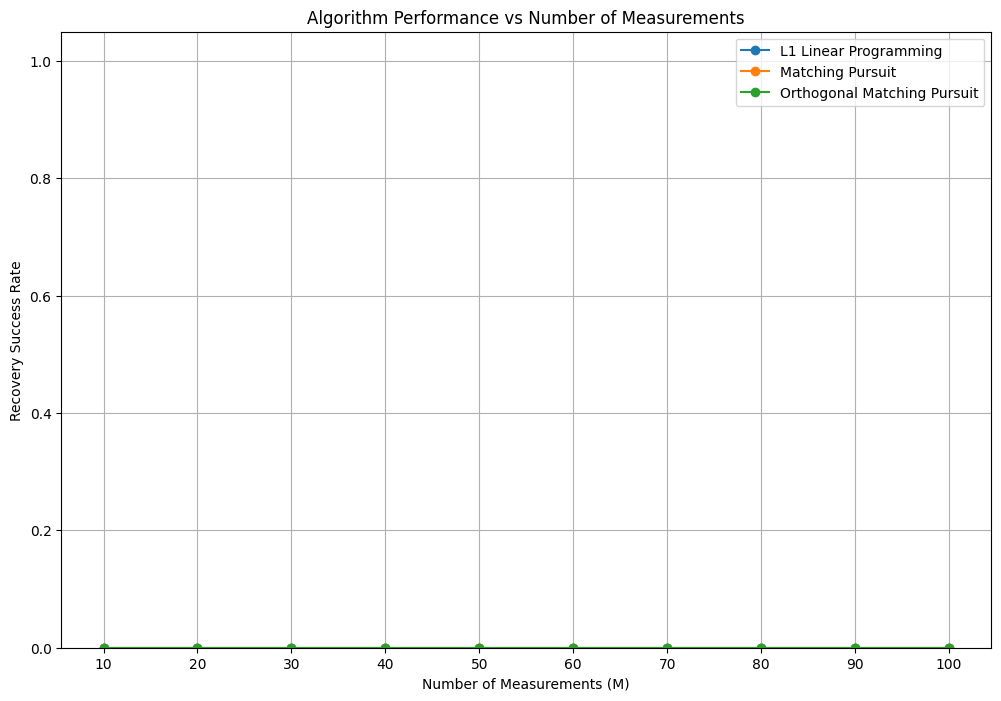

In [10]:
# Test the algorithms on the signals and plot the results for uniform subsampling
results_b = test_algorithms_on_signals(algorithms, A_list_b, x_list)
plot_algorithm_performance(results_b)

## Part c. Random sampling in the frequency domain

Suppose $F$ is the $N \times N$ Discrete Cosine Transform (DCT) matrix. Create the sensing matrix $A$ by keeping $M$ rows of $F$ at random locations.

In [11]:
from scipy.fftpack import dct, idct

# Function to generate a measurement matrix in the frequency domain (DCT)
def generate_measurement_matrix_random_frequency(M, N):
    """
    Generate a random measurement matrix in the frequency domain using the Discrete Cosine Transform (DCT).
    Each row corresponds to a random selection in the DCT matrix.
    Parameters:
        M (int): Number of measurements (rows). Must be less than N.
        N (int): Signal dimension (columns).
    Returns:
        A (ndarray): Measurement matrix of shape (M, N).
    """
    if M >= N:
        raise ValueError("M must be less than N for a valid measurement matrix.")
    
    # Create the DCT matrix of size N
    DCT_matrix = dct(np.eye(N), norm='ortho')
    
    # Randomly select M rows from the DCT matrix
    selected_rows = np.random.choice(N, M, replace=False)
    
    # Construct the measurement matrix by selecting the corresponding rows
    A = DCT_matrix[selected_rows, :]
    
    return A
    

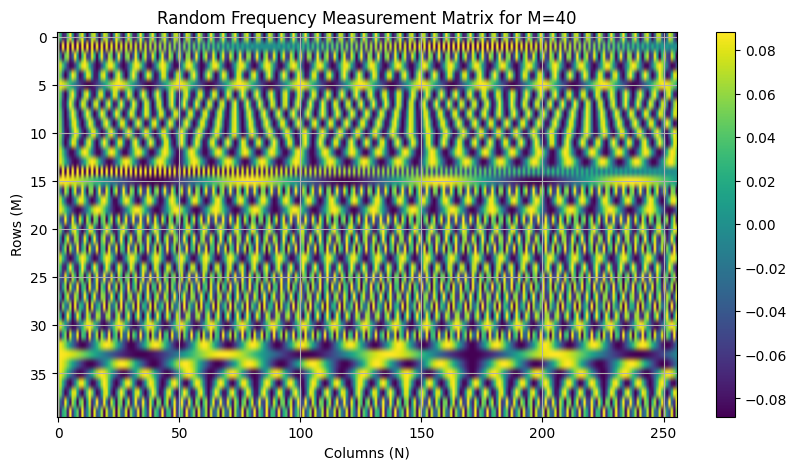

In [12]:
# Generate a lists of sensing matrices for different M
A_list_c = [generate_measurement_matrix_random_frequency(M, N) for M in M_values]
# Plot a matrix
plot_measurement_matrix(A_list_c[3], title=f"Random Frequency Measurement Matrix for M={M_values[3]}")

Testing M=100: 100%|██████████| 10/10 [00:29<00:00,  2.96s/it]


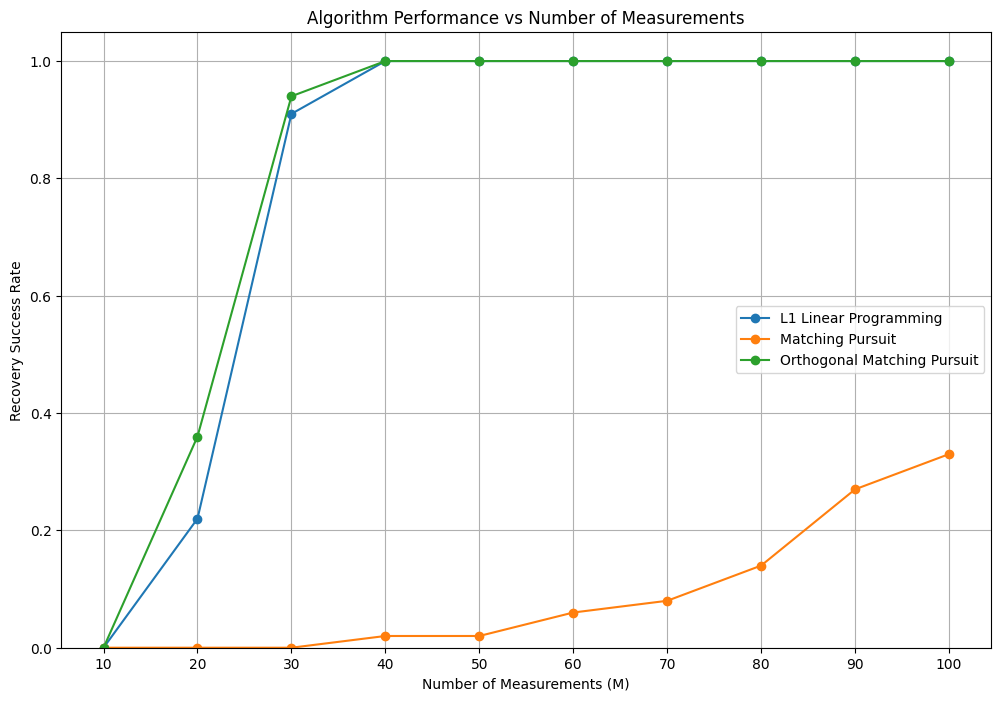

In [13]:
# Test the algorithms on the signals and plot the results for radom frequency sampling
results_c = test_algorithms_on_signals(algorithms, A_list_c, x_list)
plot_algorithm_performance(results_c)


## Part d. Low-frequency sampling

Generate the sensing matrix $A$ by keeping the first $M$ rows of the matrix $F$. 

In [14]:
# Function to generate a measurement matrix in the Fourier domain (DCT) with low-frequency subsampling
def generate_measurement_matrix_low_frequency(M, N):
    """
    Generate a measurement matrix in the frequency domain using the Discrete Cosine Transform (DCT) with low-frequency subsampling.
    Each row corresponds to a low-frequency sample in the DCT matrix.
    Parameters:
        M (int): Number of measurements (rows). Must be less than N.
        N (int): Signal dimension (columns).
    Returns:
        A (ndarray): Measurement matrix of shape (M, N).
    """
    if M >= N:
        raise ValueError("M must be less than N for a valid measurement matrix.")
    
    # Create the DCT matrix of size N
    DCT_matrix = dct(np.eye(N), norm='ortho')
    
    # Select the first M rows from the DCT matrix (corresponding to low frequencies)
    selected_rows = np.arange(M)
    
    # Construct the measurement matrix by selecting the corresponding rows
    A = DCT_matrix[selected_rows, :]
    
    return A


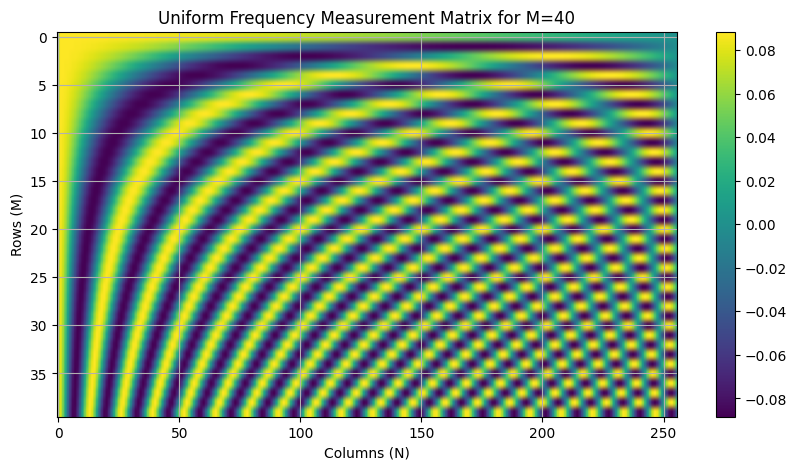

In [15]:
# Generate a lists of sensing matrices for different M
A_list_d = [generate_measurement_matrix_low_frequency(M, N) for M in M_values]
# Plot a matrix
plot_measurement_matrix(A_list_d[3], title=f"Uniform Frequency Measurement Matrix for M={M_values[3]}")

Testing M=100: 100%|██████████| 10/10 [00:54<00:00,  5.44s/it]


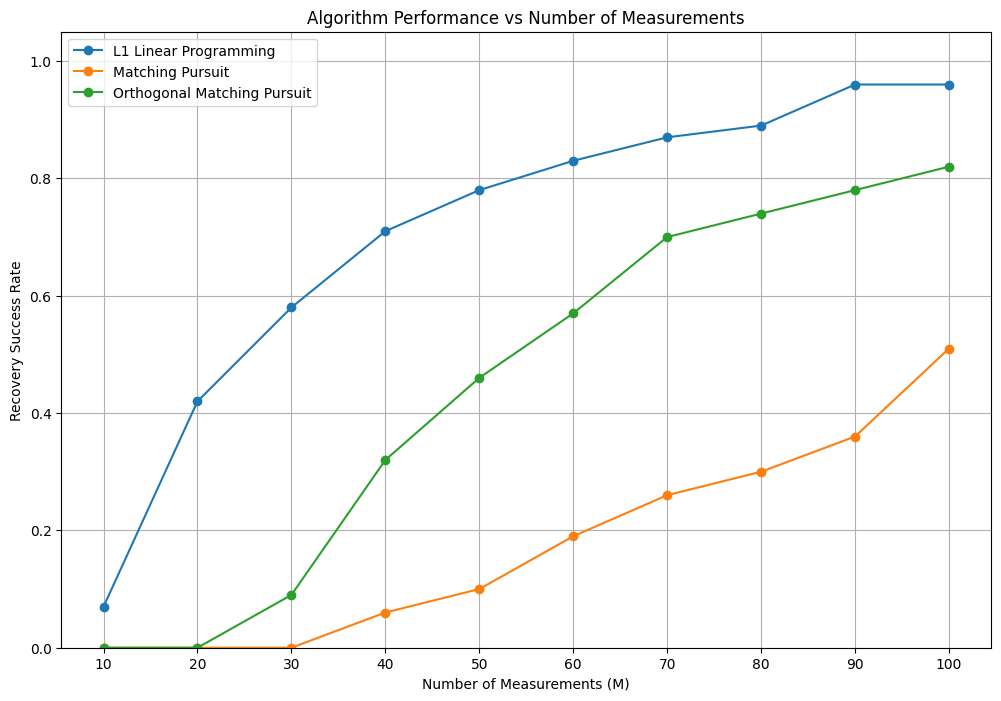

In [16]:
# Test the algorithms on the signals and plot the results for uniform frequency sampling
results_d = test_algorithms_on_signals(algorithms, A_list_d, x_list)
plot_algorithm_performance(results_d)

## Part e.  Equispaced frequency sampling

Generate the sensing matrix $A$ by keeping $M$ rows of the matrix $F$ at the uniformly-spaced locations $\{0, \lfloor N/M \rfloor, 2\lfloor N/M \rfloor, \dots, (M-1)\lfloor N/M \rfloor\}$.

In [17]:
# Function to generate a measurement matrix in the Fourier domain (DCT) with equispaced sampling
def generate_measurement_matrix_equispaced_frequency(M, N):
    """
    Generate a measurement matrix in the frequency domain using the Discrete Cosine Transform (DCT) with equispaced sampling.
    Each row corresponds to an equispaced sample in the DCT matrix.
    Parameters:
        M (int): Number of measurements (rows). Must be less than N.
        N (int): Signal dimension (columns).
    Returns:
        A (ndarray): Measurement matrix of shape (M, N).
    """
    if M >= N:
        raise ValueError("M must be less than N for a valid measurement matrix.")
    
    # Create the DCT matrix of size N
    DCT_matrix = dct(np.eye(N), norm='ortho')
    
    # Equispaced select M rows from the DCT matrix
    step = N // M
    selected_rows = np.arange(0, N, step)[:M]  # Ensure we only take M rows
    
    # Construct the measurement matrix by selecting the corresponding rows
    A = DCT_matrix[selected_rows, :]
    
    return A

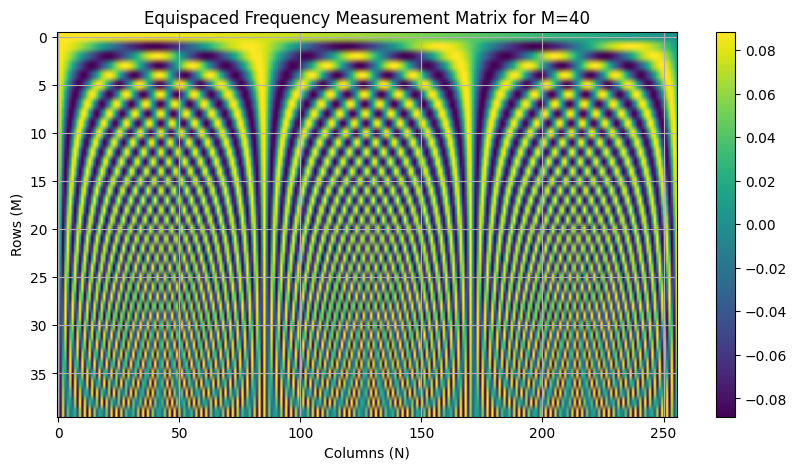

In [18]:
# Generate a lists of sensing matrices for different M
A_list_e = [generate_measurement_matrix_equispaced_frequency(M, N) for M in M_values]
# Plot a matrix
plot_measurement_matrix(A_list_e[3], title=f"Equispaced Frequency Measurement Matrix for M={M_values[3]}")

Testing M=100: 100%|██████████| 10/10 [00:33<00:00,  3.32s/it]


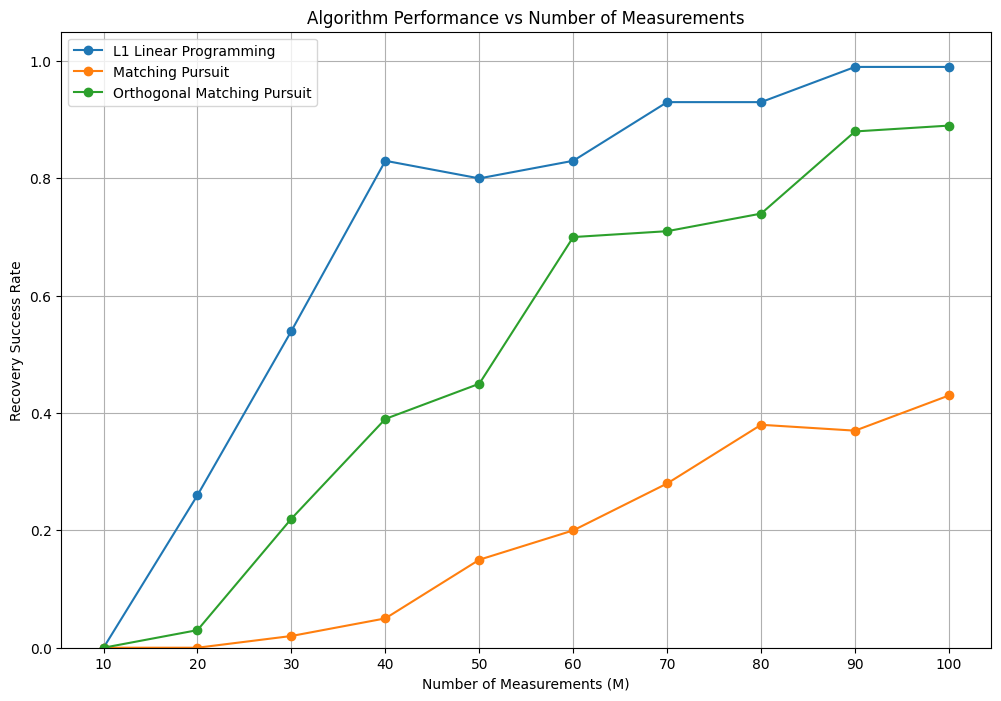

In [19]:
# Test the algorithms on the signals and plot the results for uniform frequency sampling
results_e = test_algorithms_on_signals(algorithms, A_list_e, x_list)
plot_algorithm_performance(results_e)

## Part f. Sampling in a random domain

The sensing matrix $A \in \mathbb{R}^{M \times N}$ in this case is generated from a collection of random Gaussian variables, and then the rows are orthonormalized.

In [20]:
# Function to generate an orthonormalized random measurement matrix
def generate_measurement_matrix_orthonormal_random(M, N):
    """
    Generate an orthonormalized random measurement matrix.
    Each row is a random vector that is orthogonal to the others.
    Parameters:
        M (int): Number of measurements (rows). Must be less than N.
        N (int): Signal dimension (columns).
    Returns:
        A (ndarray): Measurement matrix of shape (M, N).
    """
    if M >= N:
        raise ValueError("M must be less than N for a valid measurement matrix.")
    
    # Generate a random matrix and perform QR decomposition to orthonormalize it
    random_matrix = np.random.randn(N, N)
    Q, R = np.linalg.qr(random_matrix)
    
    # Select the first M rows of the orthonormalized matrix
    A = Q[:M, :]
    
    return A

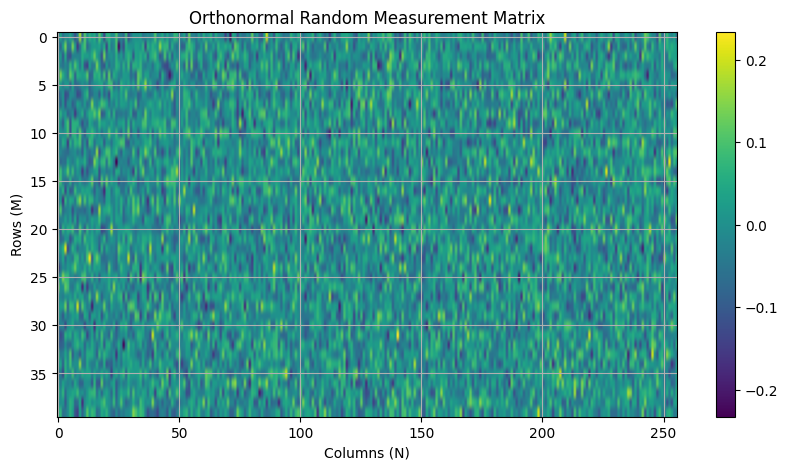

In [21]:
# Generate a lists of sensing matrices for different M
A_list_f = [generate_measurement_matrix_orthonormal_random(M, N) for M in M_values]
# Plot a matrix
plot_measurement_matrix(A_list_f[3], title=f"Orthonormal Random Measurement Matrix")

Testing M=100: 100%|██████████| 10/10 [00:26<00:00,  2.65s/it]


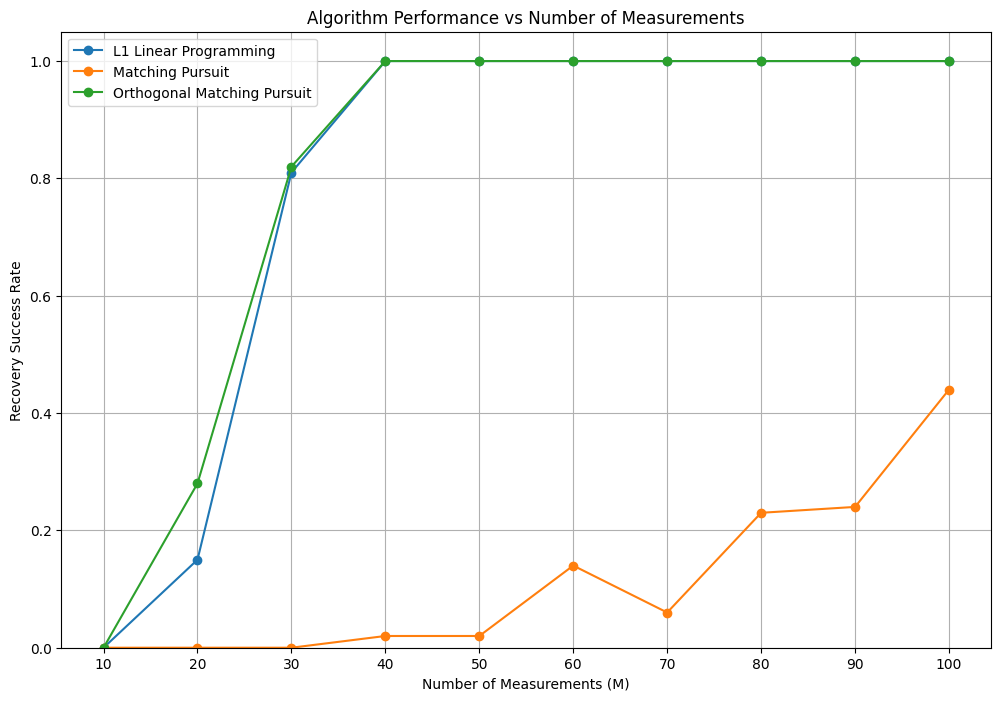

In [22]:
# Test the algorithms on the signals and plot the results for uniform frequency sampling
results_f = test_algorithms_on_signals(algorithms, A_list_f, x_list)
plot_algorithm_performance(results_f)

# Part 2

Repeat the experiments for the case where the signal is frequency-sparse, i.e., $x$ only contains $S = 5$ significant frequency components. Like the time-sparse case earlier, the location as well as the magnitude of those $S$ frequencies are unknown.

In [23]:
def generate_frequency_sparsed_signal(N, S):
    """
    Generate a frequency-sparse signal of length N with S non-zero DCT coefficients.
    Parameters:
        N (int): Signal dimension.
        S (int): Sparsity level (number of non-zero DCT coefficients).
    Returns:
        x (ndarray): Generated frequency-sparse signal of shape (N,).
    """
    # Create an array of zeros for the DCT coefficients
    dct_coefficients = np.zeros(N)
    
    # Randomly select S indices to be non-zero
    non_zero_indices = np.random.choice(N, S, replace=False)
    
    # Assign random values to the selected indices
    dct_coefficients[non_zero_indices] = np.random.randn(S)
    
    # Perform the inverse DCT to get the time-domain signal
    x = idct(dct_coefficients, norm='ortho')
    
    return x

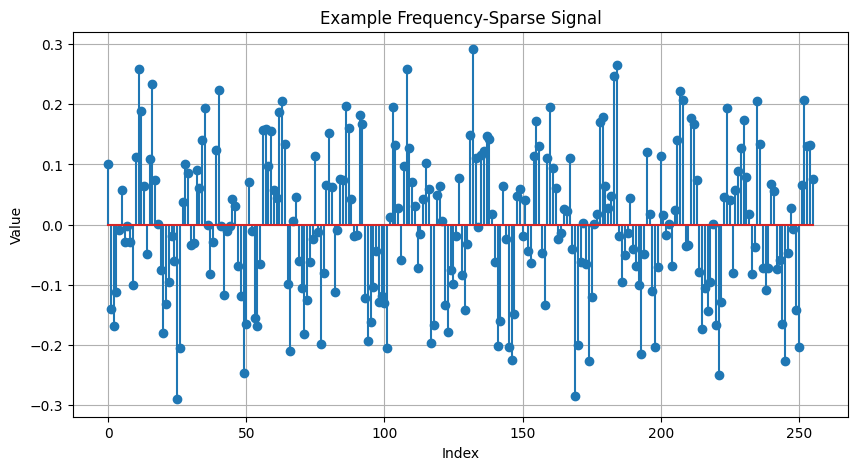

In [24]:
x_list_freq = [generate_frequency_sparsed_signal(N, S) for _ in range(100)] # Generate 100 random frequency-sparse signals
plot_solution(x_list_freq[0], title="Example Frequency-Sparse Signal")

In [25]:
# Modify l1-minimization to handle frequency-sparse signals by using the DCT basis
def solve_l1_linear_programming_frequency(A, y, S):
    """
    Solve the l1-minimization problem for frequency-sparse signals using the DCT basis.
    Parameters:
        A (ndarray): Measurement matrix of shape (M, N).
        y (ndarray): Measurement vector of shape (M,).
        S (int): Sparsity level (number of non-zero DCT coefficients).
    Returns:
        x_recovered (ndarray): Recovered signal of shape (N,).
    """
    from scipy.optimize import linprog
    
    M, N = A.shape
    
    # Create the DCT matrix
    DCT_matrix = dct(np.eye(N), norm='ortho')
    
    # Formulate the linear programming problem
    c = np.ones(2 * N)  # Objective function coefficients for the positive and negative parts
    A_ub = np.hstack((A @ DCT_matrix, -A @ DCT_matrix))  # Inequality constraints
    b_ub = y  # Measurement vector
    
    # Solve the linear programming problem
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, method='highs')
    
    if res.success:
        # Extract the DCT coefficients from the solution
        dct_coefficients = res.x[:N] - res.x[N:]  # Positive part minus negative part
        
        # Perform the inverse DCT to get the time-domain signal
        x_recovered = idct(dct_coefficients, norm='ortho')
        
        return x_recovered
    else:
        raise ValueError("Linear programming failed to find a solution.")

In [26]:
# Reuse the matrices generated from Part 1
A_lists = {
    "Random Time": A_list_a,
    "Uniform Time": A_list_b,
    "Random Frequency": A_list_c,
    "Low-Frequency": A_list_d,
    "Equispaced Frequency": A_list_e,
    "Orthonormal Random": A_list_f
}

# Test and plot results for all the matrices on the frequency-sparse signals
results_list = {}
frequency_algorithms = {
    "L1 Linear Programming (DCT)": lambda A, y: solve_l1_linear_programming_frequency(A, y, S=S),
}
for sampling_method, A_list in A_lists.items():
    results = test_algorithms_on_signals(frequency_algorithms, A_list, x_list_freq)
    results_list[sampling_method] = results

Testing M=100: 100%|██████████| 10/10 [00:21<00:00,  2.17s/it]


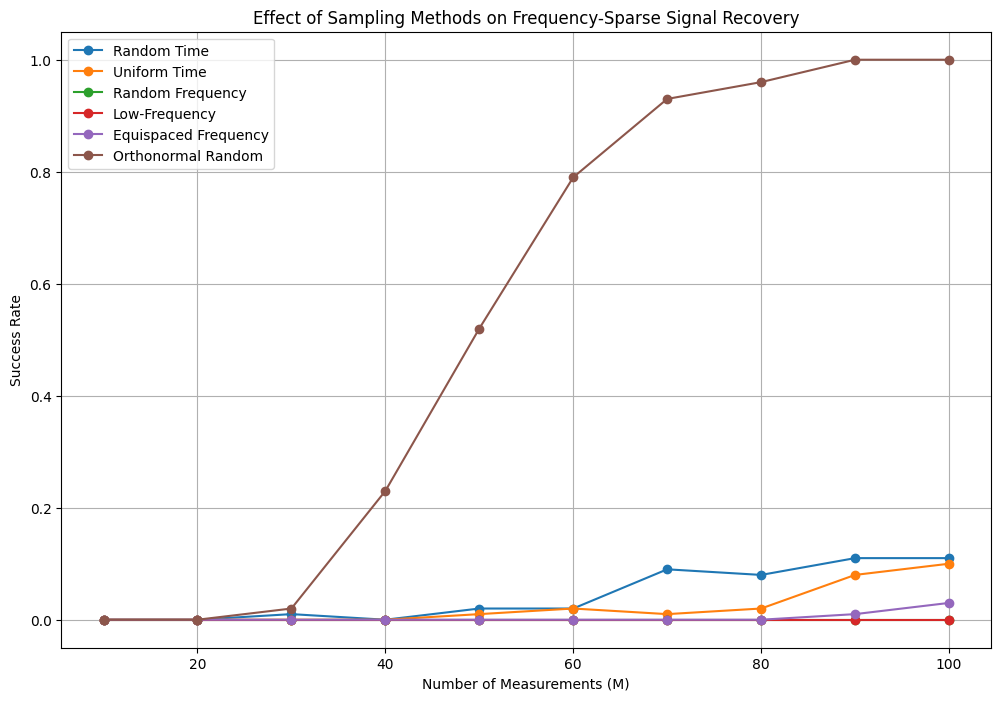

In [27]:
# Plot the effect of different sampling methods on the recovery of frequency-sparse signals
plt.figure(figsize=(12, 8))
for sampling_method, results in results_list.items():
    M_values = sorted(results["L1 Linear Programming (DCT)"].keys())
    success_rates = [np.mean(results["L1 Linear Programming (DCT)"][M]) for M in M_values]
    plt.plot(M_values, success_rates, marker='o', label=sampling_method)    

plt.xlabel("Number of Measurements (M)")
plt.ylabel("Success Rate")
plt.title("Effect of Sampling Methods on Frequency-Sparse Signal Recovery")
plt.legend()
plt.grid(True)
plt.show()

# Part 3

Test with $S=25$

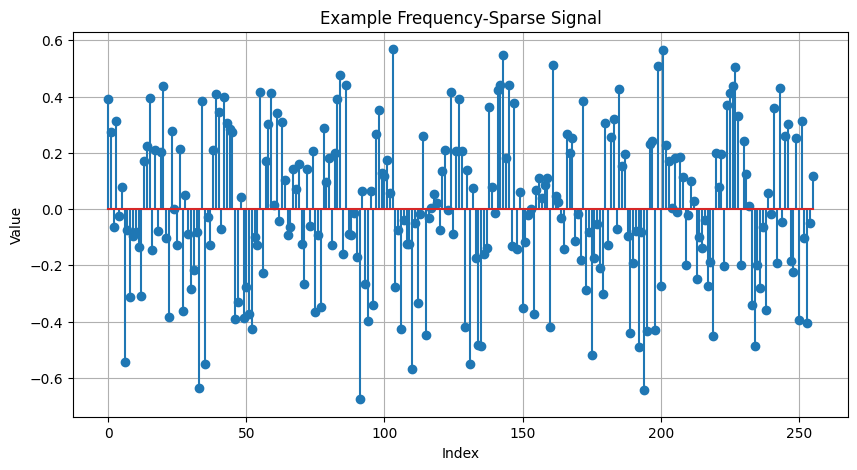

In [28]:
S = 25

x_list_freq = [generate_frequency_sparsed_signal(N, S) for _ in range(100)] # Generate 100 random frequency-sparse signals
plot_solution(x_list_freq[0], title="Example Frequency-Sparse Signal")

In [29]:
# Test and plot results for all the matrices on the frequency-sparse signals
results_list = {}
for sampling_method, A_list in A_lists.items():
    results = test_algorithms_on_signals(frequency_algorithms, A_list, x_list_freq)
    results_list[sampling_method] = results

Testing M=100: 100%|██████████| 10/10 [00:24<00:00,  2.42s/it]


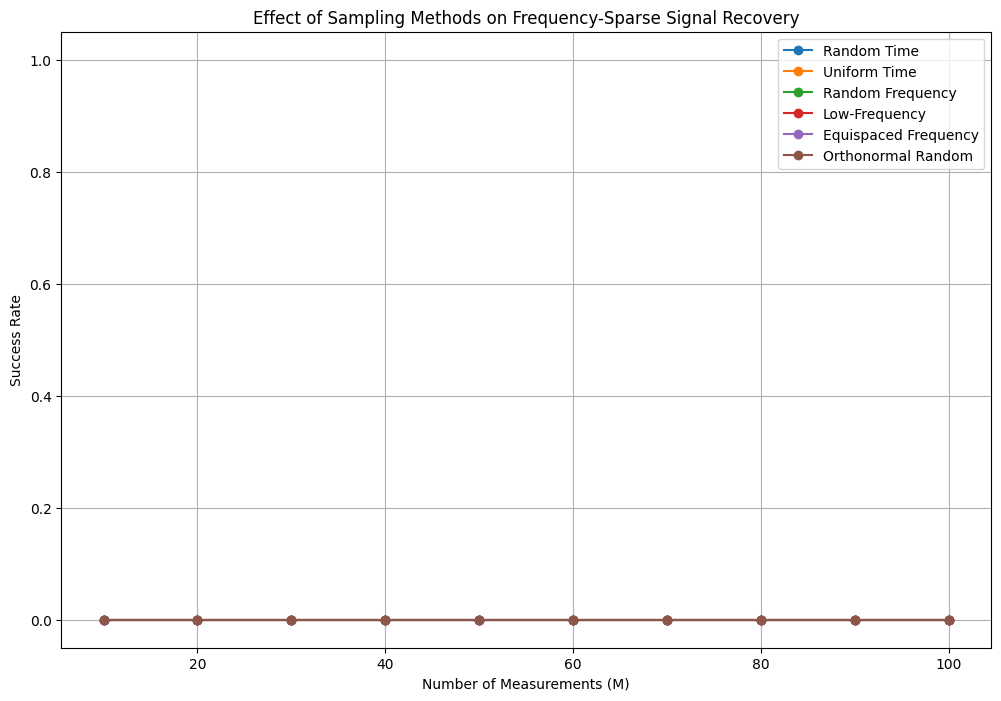

In [30]:
# Plot the effect of different sampling methods on the recovery of frequency-sparse signals
plt.figure(figsize=(12, 8))
for sampling_method, results in results_list.items():
    M_values = sorted(results["L1 Linear Programming (DCT)"].keys())
    success_rates = [np.mean(results["L1 Linear Programming (DCT)"][M]) for M in M_values]
    plt.plot(M_values, success_rates, marker='o', label=sampling_method)    

plt.xlabel("Number of Measurements (M)")
plt.ylabel("Success Rate")
plt.ylim(-0.05, 1.05)
plt.title("Effect of Sampling Methods on Frequency-Sparse Signal Recovery")
plt.legend()
plt.grid(True)
plt.show()